## Regression I: single variable regression

#### <p style="text-align: right;"> &#9989; **put your name here** </p>



<img src="https://imgs.xkcd.com/comics/extrapolating.png" width=400px>

In this module, we will practices several Python curve-fitting tools, including
1. `polyfit` in `numpy`.
2. `OLS` in `statsmodel`.
3. `curve_fit` in `scipy`.
4. `least_squares` in `scipy`.


<img src="https://community.cloudera.com/t5/image/serverpage/image-id/25068iFF075A5AEC3B8528/image-size/medium?v=1.0&px=300"> 

### 1. Linear function. 

Create a dataset of a linear function with noise.

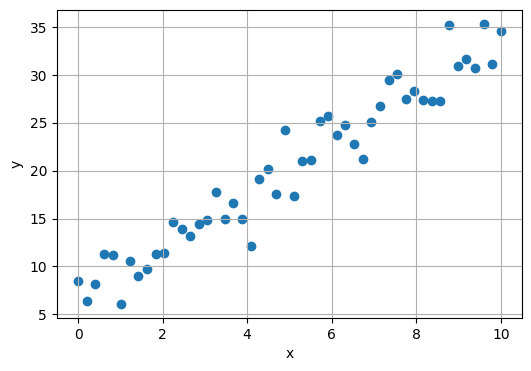

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(0)

# x values
x = np.linspace(0, 10, 50)

# true line
y_true = 3*x + 5

# add random noise
noise = np.random.normal(loc=0, scale=2, size=len(x))

y = y_true + noise

# visualization
plt.figure(figsize=(6,4))

plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

#### 1.1 `polyfit` in `numpy` library.

`np.polyfit` performs a least-squares polynomial fit. Suppose you want to fit data:

$$(x_i, y_i)$$

with a polynomial. 

**Main idea**

`polyfit` finds coefficients that minimize squared error:

$$\min \sum_i \big(y_i-p(x_i)\big)^2,$$
 
where: $p(x)$ = polynomial. Using $y = ax + b$ as an example, we shall minimize the L-2 norm of residual ($r_i = y_i - (ax_i + b)$),

$$\min \big(y_i- (ax_i+b) \big)^2$$


In matrix form,

$$\mathbf{y} = \mathbf{X} \beta,$$

where 

$$\beta = \begin{bmatrix} a \\ b \end{bmatrix}$$

and 

$$\mathbf{X} =  \begin{bmatrix} x_1 & 1 \\ x_2 & 1  \\ . \\ . \\ x_n & 1 \end{bmatrix}.$$

**Least-squares solution**

We minimize:

$$\min_\beta || \mathbf{X} \beta - \mathbf{y} ||^2 $$

where 

$$ \mathcal{F} = || \mathbf{X} \beta - \mathbf{y} ||^2 = \big(\mathbf{X} \beta - \mathbf{y}\big)^T \big(\mathbf{X} \beta - \mathbf{y}\big) = \beta^T \mathbf{X}^T \mathbf{X} \beta - 2 \mathbf{y}^T \mathbf{X} \beta + \mathbf{y}^T \mathbf{y}.$$

By solving $\partial \mathcal{F}/\partial \beta = 0$. The solution is 

$$\beta = \big( \mathbf{X}^T \mathbf{X} \big)^{-1} \mathbf{X}^T  \mathbf{y}.$$

- The cell below directly calculate the values of $\beta$. 

In [7]:
# direct calculation
X1 = x.reshape(-1,1)
X0 = np.ones((len(x),1))
X = np.hstack((X1, X0))
Y = y.reshape(-1,1)

beta = np.linalg.inv(X.T @ X) @ X.T @ Y

slope_cal = beta[0, 0]
intercept_cal = beta[1, 0]

print("slope =", slope_cal)
print("intercept =", intercept_cal)

slope = 2.7176755014019625
intercept = 6.692741037616383


- The cell below uses the built-in function `polyfit`.

In [9]:
# np.polyfit
p = np.polyfit(x, y, 1)

slope_poly = p[0]
intercept_poly = p[1]

print("polyfit slope =", p[0])
print("polyfit intercept =", p[1])

polyfit slope = 2.717675501401962
polyfit intercept = 6.69274103761638


### 1.2 `OLS` ordinary least square fitting.

Below, we use `OLS` function in `statsmodels` library to fit the data.
- import the library
- add constant. This makes the design matrix:

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ . \\ . \\ 1 & x_n \end{bmatrix}$$

- extract slope and intercept.


In [13]:
# statsmodel
import statsmodels.api as sm

# x and y from your example
X = sm.add_constant(x)   # adds intercept column

# initialize a model_OLS object
model_OLS = sm.OLS(y, X)
results_OLS = model_OLS.fit()

print(results_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     702.7
Date:                Sun, 17 May 2026   Prob (F-statistic):           2.58e-30
Time:                        14:23:57   Log-Likelihood:                -107.85
No. Observations:                  50   AIC:                             219.7
Df Residuals:                      48   BIC:                             223.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6927      0.595     11.250      0.0

&#9989; Do this: What are R$^2$ value and $p$ value in statistics?

In [15]:
intercept_OLS = results_OLS.params[0]
slope_OLS = results_OLS.params[1]

print("slope =", slope_OLS)
print("intercept =", intercept_OLS)

slope = 2.717675501401963
intercept = 6.6927410376163845


#### 1.3 `curve_fit` method in `scipy.optimiza` library 

Mathematically, `curve_fit` minimizes:

$$\min_i \big(y-f(x_i, p)\big)^2$$

where: $p$ = fitting parameters. For the linear model:

$$f(x,a,b)=ax+b.$$

Below we 
- define the function to be fitted.
- use `curve_fit`.


In [19]:
def linear_model(x, a, b):
    return a*x + b

In [23]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(linear_model, x, y)

slope_cf = popt[0]
intercept_cf = popt[1]

print("slope =", slope)
print("intercept =", intercept)


slope = 2.7176755014019625
intercept = 6.692741037616383


array([[ 0.01051067, -0.05255334],
       [-0.05255334,  0.35393066]])

In [25]:
print(pcov)

[[ 0.01051067 -0.05255334]
 [-0.05255334  0.35393066]]


&#9989; Do this: What is `pcov`? What do values mean?

#### 1.4 Use `least_squares` in `scipy.optimize` library. 

This should be familiar to you because we have use it in finding common tangent lines before.

Mathematically, `least_squares` minimizes:

$$\min_i \big(r_i \big)^2,$$

where:

$$r_i = ax_i+b - y_i.$$

Below, the code
- define the residual.
- find the solution that minimizes the residual.


In [30]:
def residual(p, x, y):
    a, b = p
    return a*x + b - y

In [32]:
from scipy.optimize import least_squares

res_ls = least_squares(residual, x0=[1,1], args=(x,y))

slope_ls = res_ls.x[0]
intercept_ls = res_ls.x[1]

print("slope =", slope_ls)
print("intercept =", intercept_ls)

slope = 2.717675499892486
intercept = 6.692741060516397


**Now, let's plot the results from all these methods.**

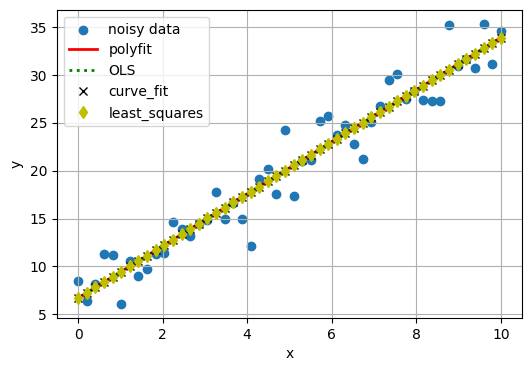

In [35]:
# visualization
# evaluate fitted polynomial
y_polyfit = np.polyval(p, x)

# evaluate fitted OLS model
y_OLS = results_OLS.predict(X)

# evaluate fitted curve_fit model
y_cf = linear_model(x, *popt)

# evaluate fitted curve_fit model
y_ls = linear_model(x, slope_ls, intercept_ls)

plt.figure(figsize=(6,4))

plt.scatter(x, y, label='noisy data')
plt.plot(x, y_polyfit, 'r', linewidth=2, label='polyfit')
plt.plot(x, y_OLS, 'g:', linewidth=2, label='OLS')
plt.plot(x, y_cf, 'kx', linewidth=2, label='curve_fit')
plt.plot(x, y_ls, 'yd', linewidth=2, label='least_squares')


plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

Note that, in `curve_fit`, we define the function, but in `least_squares`, we define the residual. Note that `least_squares` is more flexible. Recall the common tangent problem, `least_squares` finds the roots for multiple equations.

---
### More practices on regression.



Here, let's practice these methods for fitting a 4th order function. 

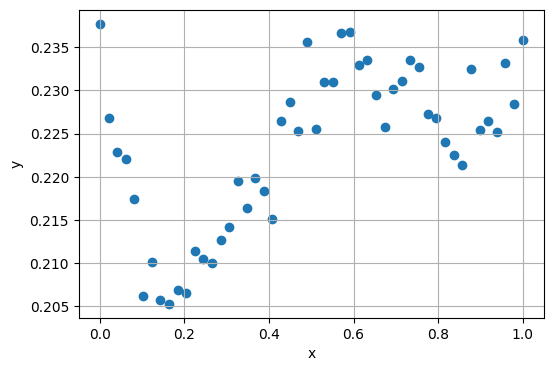

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(0)

# x values
x = np.linspace(0, 1, 50)

# true line
y_true = ((x-0.2)**2 * (0.9-x)**2)*1 + (0.03*x + 0.2)*1

# add random noise
noise = np.random.normal(loc=0, scale=0.003, size=len(x))

y = y_true + noise

plt.figure(figsize=(6,4))

plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

For a 4th-order polynomial, you will get coefficients for `np.polyfit`:

$$ax^4+bx^3+cx^2+dx+e.$$

In [41]:
# polynomial fit
degree = 4

p = np.polyfit(x, y, degree)
print(p)

# evaluate fitted polynomial
y_polyfit = np.polyval(p, x)

[ 1.03989631 -2.29974991  1.65365953 -0.39591601  0.23683095]


- use `curve_fit`.

In [43]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def poly4(x, a, b, c, d, e):
    return a*x**4 + b*x**3 + c*x**2 + d*x + e

popt, pcov = curve_fit(poly4, x, y)

a, b, c, d, e = popt

print("a =", a)
print("b =", b)
print("c =", c)
print("d =", d)
print("e =", e)

y_curvefit = poly4(x, *popt)

a = 1.0398963167183028
b = -2.299749917350602
c = 1.653659542541988
d = -0.39591601273798893
e = 0.23683095213732275


- Use `least_squares`

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# residual function
def residual(p, x, y):
    a, b, c, d, e = p
    y_model = poly4(x, a, b, c, d, e)
    return y_model - y

# initial guess
p0 = [1, 1, 1, 1, 1]

# optimization
res = least_squares(residual, p0, args=(x, y))

# fitted coefficients
a, b, c, d, e = res.x

print("a =", a)
print("b =", b)
print("c =", c)
print("d =", d)
print("e =", e)

# fitted curve
y_ls = poly4(x, a, b, c, d, e)


a = 1.0398962402268865
b = -2.2997497577252717
c = 1.6536594346909887
d = -0.39591598740145467
e = 0.23683095083312


---
#### Visualization

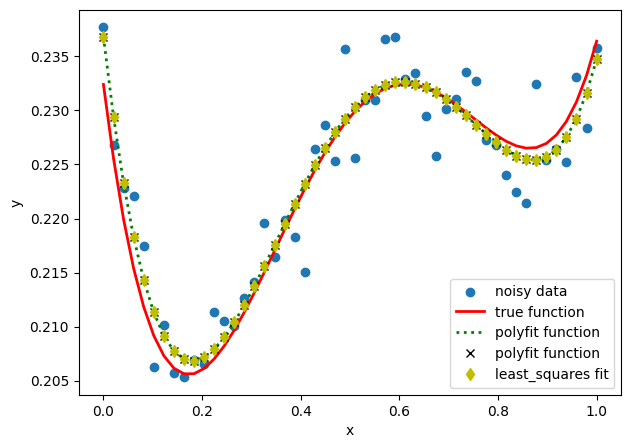

In [52]:
plt.figure(figsize=(7,5))

plt.scatter(x, y, label='noisy data')

plt.plot(x, y_true, 'r', linewidth=2, label='true function')
plt.plot(x, y_polyfit, 'g:', linewidth=2, label='polyfit function')
plt.plot(x, y_curvefit, 'kx', linewidth=2, label='polyfit function')
plt.plot(x, y_ls, 'yd', linewidth=2, label='least_squares fit')

plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.show()

&#9989; Do this: Why do the fitted results deviate from the true function? 